# Quality‑Aware Decoding для машинного перевода

В данном проекте будет реализован метод quality‑aware decoding, предложенный в статье «Quality‑Aware Decoding for Neural Machine Translation» (Fernandes et al., NAACL 2022) (https://aclanthology.org/2022.naacl-main.191/).

Суть метода заключается в том, что при генерации перевода создаётся несколько кандидатов, а затем они ранжируются с помощью reference‑free метрики качества (COMET‑QE). Это позволяет выбрать перевод, который не обязательно самый вероятный по модели, но лучше с точки зрения естественности и смысловой близости к тому, как сказал бы человек.

Используемые модели и датасет:
- Модель перевода: "Helsinki-NLP/opus-mt-en-fr", переводит с английского на французский.  
- Метрика для ранжирования: "Unbabel/wmt20-comet-qe-da" – reference‑free версия COMET, обученная предсказывать качество перевода без эталона.  
- Финальная оценка: "Unbabel/wmt22-comet-da" – reference‑based COMET (использует эталон) для объективного сравнения качества переводов.  
- Датасет: "enimai/MuST-C-fr" – корпус из TED‑лекций с английскими фразами и их французскими переводами. Взят тестовый сплит (первые 100 примеров для демонстрации работы метода).


# Импорты

In [ ]:
!pip install -U pip -q
!pip install transformers datasets sentencepiece sacremoses -q
!pip install "unbabel-comet>=2.2.0" -q

import logging
import warnings
warnings.filterwarnings("ignore")
logging.getLogger("pytorch_lightning").setLevel(logging.WARNING)

In [ ]:
import torch
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import MarianMTModel, MarianTokenizer
from comet import download_model, load_from_checkpoint

# Загрузка моделей и датасета

Модель для финальной оценки (reference-based)

In [ ]:
comet_ref_path = download_model("Unbabel/wmt22-comet-da")
comet_ref = load_from_checkpoint(comet_ref_path)

Модель для переранжирования (reference-free)

In [ ]:
comet_qe_path = download_model("Unbabel/wmt20-comet-qe-da")
comet_qe = load_from_checkpoint(comet_qe_path)

Модель для перевода

In [ ]:
model_name = "Helsinki-NLP/opus-mt-en-fr"
tokenizer = MarianTokenizer.from_pretrained(model_name)
model = MarianMTModel.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

Датасет

In [ ]:
dataset = load_dataset("enimai/MuST-C-fr", split="test[:100]")
dataset[0]

# Необходимые функции

Жадный поиск

In [ ]:
def translate_baseline(text):
    tokens = tokenizer(text, return_tensors="pt", truncation=True).to(device)
    with torch.no_grad():
        output = model.generate(**tokens)
    return tokenizer.decode(output[0], skip_special_tokens=True)

Лучевой поиск

In [ ]:
def generate_beam_candidates(text, n):
    tokens = tokenizer(text, return_tensors="pt", truncation=True).to(device)
    with torch.no_grad():
        outputs = model.generate(**tokens, num_beams=n, num_return_sequences=n)
    return [tokenizer.decode(o, skip_special_tokens=True) for o in outputs]

Генерация n кандидатов сэмплированием

In [ ]:
def generate_sampling_candidates(text, n, top_p=0.9):
    tokens = tokenizer(text, return_tensors="pt", truncation=True).to(device)
    with torch.no_grad():
        outputs = model.generate(**tokens, do_sample=True, top_p=top_p, num_beams=1, num_return_sequences=n)
    return [tokenizer.decode(o, skip_special_tokens=True) for o in outputs]

Функция ранжирования с COMET‑QE

In [ ]:
def rerank_with_comet_qe(source, candidates):
    data = [{"src": source, "mt": cand} for cand in candidates]
    scores = comet_qe.predict(data, batch_size=8)["scores"]
    best_index = scores.index(max(scores))
    return candidates[best_index]

# Эксперимент

Для каждого примера из выборки:
1. Получим базовый перевод.
2. Сгенерируем 10 кандидатов лучевым поиском и сэмплированием и проранжируем их.
3. Сохраним все переводы для последующей оценки.

In [ ]:
n_candidates = 10

baseline_preds = []
beam_reranked_preds = []
sampling_reranked_preds = []
references = []

for i, item in enumerate(dataset):
    src = item["en"]
    ref = item["fr"]

    baseline = translate_baseline(src)

    beam_candidates = generate_beam_candidates(src, n_candidates)
    beam_best = rerank_with_comet_qe(src, beam_candidates)

    sampling_candidates = generate_sampling_candidates(src, n_candidates, top_p=0.9)
    sampling_best = rerank_with_comet_qe(src, sampling_candidates)

    baseline_preds.append(baseline)
    beam_reranked_preds.append(beam_best)
    sampling_reranked_preds.append(sampling_best)
    references.append(ref)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00,  5.70it/s]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU

# Оценка перевода

Оценим качество перевода с помощью метрик COMET и BLEU

In [ ]:
def evaluate_comet(srcs, mts, refs):
    data = [{"src": s, "mt": m, "ref": r} for s, m, r in zip(srcs, mts, refs)]
    score = comet_ref.predict(data, batch_size=64)["system_score"]
    return score

sources = [x["en"] for x in dataset]

baseline_score = evaluate_comet(sources, baseline_preds, references)
beam_score = evaluate_comet(sources, beam_reranked_preds, references)
sampling_score = evaluate_comet(sources, sampling_reranked_preds, references)

print(f"Baseline COMET: {baseline_score:.4f}")
print(f"Beam Rerank COMET: {beam_score:.4f}")
print(f"Sampling Rerank COMET: {sampling_score:.4f}")

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Predicting DataLoader 0: 100%|██████████| 2/2 [00:02<00:00,  1.48s/it]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU

Baseline COMET: 0.8465
Beam Rerank COMET: 0.8507
Sampling Rerank COMET: 0.8284


По метрике COMET метод quality‑aware decoding с лучевым поиском (beam rerank) даёт лучший результат, чем базовый жадный перевод: средний балл вырос с 0.8465 до 0.8507. Sampling rerank, напротив, ухудшил качество (0.8284). Сэмплирование оказалось менее стабильным для генерации кандидатов в этой задаче.

Получим по-предложные оценки для более детального сравнения

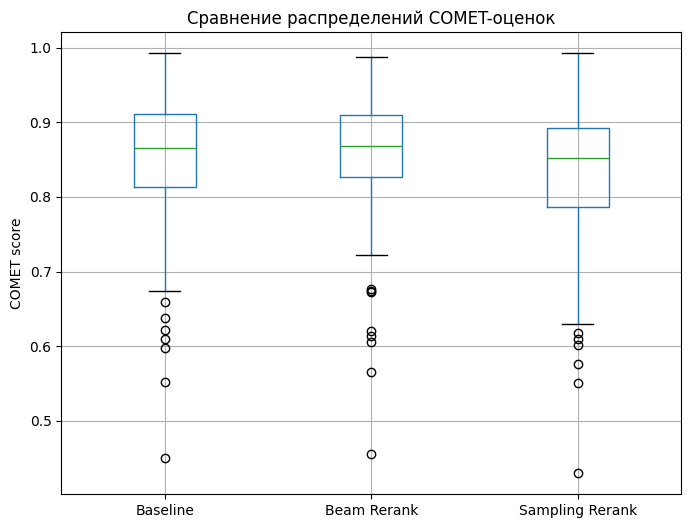

In [ ]:
import pandas as pd

df = pd.DataFrame({
    'Baseline': baseline_scores,
    'Beam Rerank': beam_scores,
    'Sampling Rerank': sampling_scores
})
plt.figure(figsize=(8,6))
df.boxplot()
plt.ylabel('COMET score')
plt.title('Сравнение распределений COMET-оценок')
plt.show()

На графике распределений COMET-оценок видно, что baseline и beam rerank имеют схожие медианы и межквартильные размахи, но у beam rerank чуть больше оценок в верхней части диапазона. Sampling rerank показывает гораздо более широкий разброс и много низких значений, что подтверждает его нестабильность для данной задачи.

Посмотрим также на оценку BLEU

In [ ]:
import sacrebleu

def evaluate_bleu(hyps, refs):
    bleu = sacrebleu.corpus_bleu(hyps, [refs])
    return bleu.score

baseline_bleu = evaluate_bleu(baseline_preds, references)
beam_bleu = evaluate_bleu(beam_reranked_preds, references)
sampling_bleu = evaluate_bleu(sampling_reranked_preds, references)

print(f"Baseline BLEU:         {baseline_bleu:.2f}")
print(f"Beam Rerank BLEU:      {beam_bleu:.2f}")
print(f"Sampling Rerank BLEU:  {sampling_bleu:.2f}")

Baseline BLEU:         45.04
Beam Rerank BLEU:      44.36
Sampling Rerank BLEU:  29.97


BLEU для beam rerank (44.36) оказался немного ниже baseline (45.04), а для sampling rerank падение более выражено (29.97). Как отмечают авторы статьи, лексические метрики, основанные на совпадении n‑грамм, слабо коррелируют с человеческой оценкой качества перевода. В отличие от них, обучаемые метрики (например, COMET) специально настраиваются на предсказание человеческих предпочтений и потому лучше отражают смысловую близость, а не лексическое сходство.

Таким образом, небольшое снижение BLEU при незначительном росте COMET для beam rerank не противоречит основному выводу статьи: quality‑aware decoding способен улучшить перевод с точки зрения семантики, даже если BLEU этого не фиксирует.

# Примеры

In [ ]:
import random

random.seed(21)
indices = random.sample(range(len(sources)), 10)

for i, idx in enumerate(indices, 1):
    print(f"{i}) Исходный текст: {sources[idx]}")
    print(f"Эталон:         {references[idx]}")
    print(f"Baseline:       {baseline_preds[idx]}")
    print(f"Beam Rerank:    {beam_reranked_preds[idx]}")
    print(f"Sampling Rerank: {sampling_reranked_preds[idx]}\n")

1) Исходный текст: Don't wait until you make your first million to make a difference in somebody's life.
Эталон:         N'attendez pas d'avoir gagné votre premier million pour faire la différence dans la vie de quelqu'un.
Baseline:       N'attendez pas que vous fassiez votre premier million pour faire une différence dans la vie de quelqu'un.
Beam Rerank:    N'attendez pas de faire votre premier million pour faire une différence dans la vie de quelqu'un.
Sampling Rerank: N'attendez pas que vous faites votre premier million pour changer les choses dans la vie de quelqu'un.

2) Исходный текст: Play increases creativity and resilience, and it's all about the generation of diversity — diversity of interactions, diversity of behaviors, diversity of connections.
Эталон:         Jouer augmente la créativité et la résistance, et tout ceci relève de la diversité — la diversité des interactions, diversité des comportements, diversité des connections.
Baseline:       Le jeu augmente la créativité

Beam rerank в большинстве случаев выбирает перевод, который либо максимально близок к эталону, либо исправляет неточности baseline.

В примере 5 он заменяет неверное agression "агрессия" на правильное agressivité "агрессивность".

В примере 10 исправляет ошибочное soupe-cuisine "суповая кухня" на soupe populaire "бесплатная столовая".

В примере 1 улучшает синтаксис, выбирает более естественную конструкцию de faire "сделать" вместо que vous fassiez "чтобы вы сделали".

Даже там, где baseline уже точен (пример 2), beam rerank предлагает стилистически приемлемую альтернативу (accroît вместо augmente - оба означают "увеличивает").

Sampling rerank часто перефразирует и упрощает высказывания (примеры 2, 9), содержит смысловые неточности (примеры 8, 10) (trouvé "нашла" вместо eu "имела", restez "оставайтесь" вместо soyez "будьте").

Baseline ошибается редко, но не может исправить ошибки. Примеры 5 и 10 показывают, что без дополнительного ранжирования модель может выбрать не самый удачный вариант.

В целом качественный анализ подтверждает количественные результаты COMET: beam rerank действительно способен улучшать перевод, особенно в тех случаях, где baseline допускает лексические или синтаксические неточности.

# Телеграм-бот

Для демонстрации работы метода был создан телеграм-бот, который позволяет пользователю отправить текст на английском языке и получить два варианта перевода на французский: стандартный перевод и улучшенный перевод, выбранный методом quality‑aware decoding

In [ ]:
!pip install pyTelegramBotAPI

import telebot

token = "YOUR_TELEGRAM_BOT_TOKEN"
bot = telebot.TeleBot(token)

@bot.message_handler(commands=['start'])
def send_welcome(message):
    bot.reply_to(message, "Please send an English text to compare a baseline translation (greedy decoding) with an improved translation (reranked using COMET-QE).")

@bot.message_handler(func=lambda message: True)
def handle_message(message):
    src = message.text
    baseline = translate_baseline(src)
    candidates = generate_beam_candidates(src, 5)
    beam_best = rerank_with_comet_qe(src, candidates)
    bot.reply_to(message, f"*Baseline:* {baseline}\n\n*Reranked:* {beam_best}", parse_mode='Markdown')

bot.polling()

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
Predicting DataLoader 0: 100%|██████████| 1/1 [00:04<00:00,  4.04s/it]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and exper

# Вывод

Эксперимент показал, что метод quality‑aware decoding работает: ранжирование кандидатов с помощью reference‑free метрики COMET‑QE позволило получить переводы, которые в среднем оказались ближе к человеческим предпочтениям. Лучевой поиск с последующим ранжированием показал более стабильные и качественные результаты, чем сэмплирование, которое часто приводило к смысловым и грамматическим ошибкам.

Количественные оценки COMET (обучаемой на человеческих суждениях) и качественный анализ примеров подтверждают, что даже небольшое улучшение по такой метрике действительно отражает рост естественности и точности перевода. При этом лексические метрики, в данной работе BLEU, могут не фиксировать эти улучшения. Это согласуется с тем, что авторы статьи говорят о недостатках n‑граммных метрик.

Таким образом, quality‑aware decoding можно считать эффективным способом повышения качества перевода без дообучения модели, особенно при использовании лучевого поиска для генерации кандидатов.